In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('house_pred_data.csv')

In [3]:
df.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,13300000
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,12250000
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,12250000
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,12215000
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,11410000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   area              545 non-null    int64 
 1   bedrooms          545 non-null    int64 
 2   bathrooms         545 non-null    int64 
 3   stories           545 non-null    int64 
 4   mainroad          545 non-null    object
 5   guestroom         545 non-null    object
 6   basement          545 non-null    object
 7   hotwaterheating   545 non-null    object
 8   airconditioning   545 non-null    object
 9   parking           545 non-null    int64 
 10  prefarea          545 non-null    object
 11  furnishingstatus  545 non-null    object
 12  price             545 non-null    int64 
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
df.isnull().sum()

area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
price               0
dtype: int64

In [6]:
df.drop('prefarea', axis=1, inplace=True)

In [7]:
df.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,furnishingstatus,price
0,7420,4,2,3,yes,no,no,no,yes,2,furnished,13300000
1,8960,4,4,4,yes,no,no,no,yes,3,furnished,12250000
2,9960,3,2,2,yes,no,yes,no,no,2,semi-furnished,12250000
3,7500,4,2,2,yes,no,yes,no,yes,3,furnished,12215000
4,7420,4,1,2,yes,yes,yes,no,yes,2,furnished,11410000


In [8]:
columns_to_convert = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning']
for column in columns_to_convert:
    df[column] = df[column].map({'yes': 1, 'no': 0}).astype(int)

In [9]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()

In [10]:
furnished_encoded = encoder.fit_transform(df[['furnishingstatus']]).toarray()

In [11]:
furnished_df = pd.DataFrame(furnished_encoded, columns = encoder.get_feature_names_out())

In [12]:
df.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,furnishingstatus,price
0,7420,4,2,3,1,0,0,0,1,2,furnished,13300000
1,8960,4,4,4,1,0,0,0,1,3,furnished,12250000
2,9960,3,2,2,1,0,1,0,0,2,semi-furnished,12250000
3,7500,4,2,2,1,0,1,0,1,3,furnished,12215000
4,7420,4,1,2,1,1,1,0,1,2,furnished,11410000


In [13]:
df.drop(columns = 'furnishingstatus', axis = 1, inplace = True) 

In [14]:
df_copy = pd.concat([df, furnished_df], axis = 1)

In [15]:
df_copy.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,price,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,13300000,1.0,0.0,0.0
1,8960,4,4,4,1,0,0,0,1,3,12250000,1.0,0.0,0.0
2,9960,3,2,2,1,0,1,0,0,2,12250000,0.0,1.0,0.0
3,7500,4,2,2,1,0,1,0,1,3,12215000,1.0,0.0,0.0
4,7420,4,1,2,1,1,1,0,1,2,11410000,1.0,0.0,0.0


In [16]:
df_copy = df_copy[[col for col in df_copy if col != 'price'] + ['price']]

In [17]:
df_copy.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,price
0,7420,4,2,3,1,0,0,0,1,2,1.0,0.0,0.0,13300000
1,8960,4,4,4,1,0,0,0,1,3,1.0,0.0,0.0,12250000
2,9960,3,2,2,1,0,1,0,0,2,0.0,1.0,0.0,12250000
3,7500,4,2,2,1,0,1,0,1,3,1.0,0.0,0.0,12215000
4,7420,4,1,2,1,1,1,0,1,2,1.0,0.0,0.0,11410000


In [18]:
df_copy.shape

(545, 14)

In [19]:
df = df_copy

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['area'] = np.log10(df['area'])
df['area'] = scaler.fit_transform(df[['area']])

<Axes: xlabel='area', ylabel='Count'>

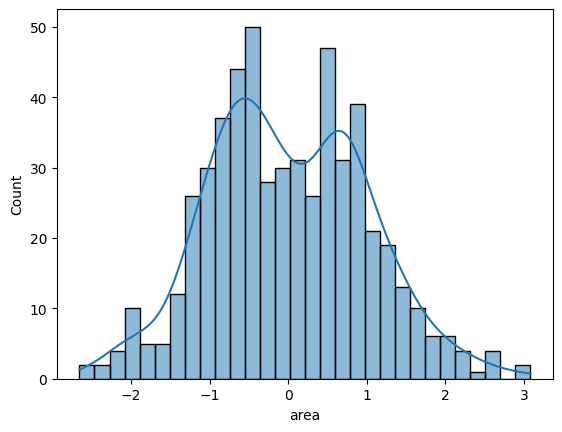

In [21]:
sns.histplot(data = df, x = 'area', bins = 30, kde = True)

In [22]:
df.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,price
0,1.119319,4,2,3,1,0,0,0,1,2,1.0,0.0,0.0,13300000
1,1.593264,4,4,4,1,0,0,0,1,3,1.0,0.0,0.0,12250000
2,1.859165,3,2,2,1,0,1,0,0,2,0.0,1.0,0.0,12250000
3,1.146269,4,2,2,1,0,1,0,1,3,1.0,0.0,0.0,12215000
4,1.119319,4,1,2,1,1,1,0,1,2,1.0,0.0,0.0,11410000


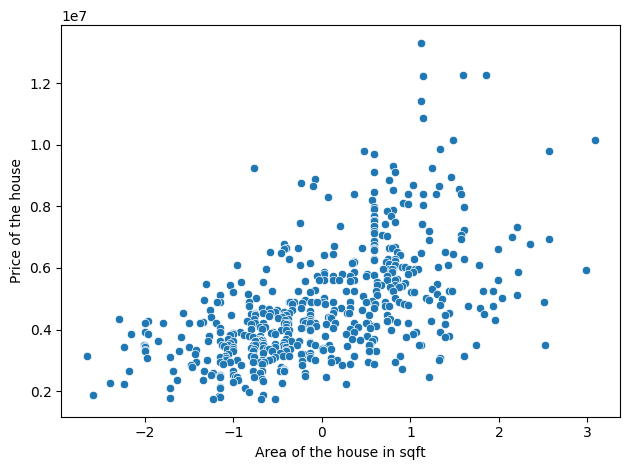

In [23]:
sns.scatterplot(x = df['area'], y = df['price'])
plt.xlabel('Area of the house in sqft')
plt.ylabel('Price of the house')
plt.tight_layout()

<Axes: >

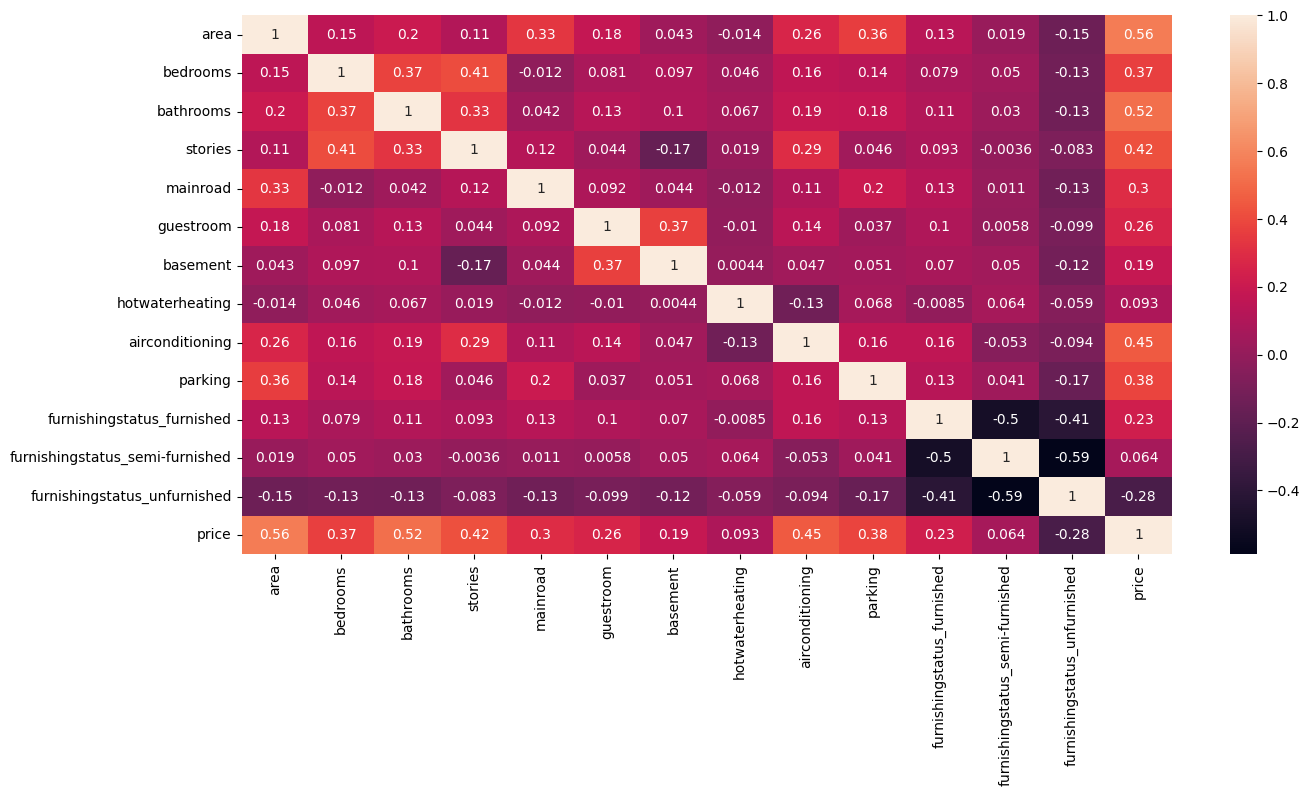

In [24]:
plt.figure(figsize= (15, 7))
sns.heatmap(df.corr(), annot = True)

In [25]:
df['furnishingstatus_furnished'] = df['furnishingstatus_furnished'].astype(int)
df['furnishingstatus_unfurnished'] = df['furnishingstatus_unfurnished'].astype(int)
df['furnishingstatus_semi-furnished'] = df['furnishingstatus_semi-furnished'].astype(int)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   area                             545 non-null    float64
 1   bedrooms                         545 non-null    int64  
 2   bathrooms                        545 non-null    int64  
 3   stories                          545 non-null    int64  
 4   mainroad                         545 non-null    int32  
 5   guestroom                        545 non-null    int32  
 6   basement                         545 non-null    int32  
 7   hotwaterheating                  545 non-null    int32  
 8   airconditioning                  545 non-null    int32  
 9   parking                          545 non-null    int64  
 10  furnishingstatus_furnished       545 non-null    int32  
 11  furnishingstatus_semi-furnished  545 non-null    int32  
 12  furnishingstatus_unfur

In [27]:
X = df.iloc[ : , : -1]
y = df.iloc[ : , -1]

In [28]:
df.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,price
0,1.119319,4,2,3,1,0,0,0,1,2,1,0,0,13300000
1,1.593264,4,4,4,1,0,0,0,1,3,1,0,0,12250000
2,1.859165,3,2,2,1,0,1,0,0,2,0,1,0,12250000
3,1.146269,4,2,2,1,0,1,0,1,3,1,0,0,12215000
4,1.119319,4,1,2,1,1,1,0,1,2,1,0,0,11410000


In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 5, test_size = 0.2)

In [30]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((436, 13), (109, 13), (436,), (109,))

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [32]:
X_train_scaled = scaler.fit_transform(X_train)

In [33]:
X_test_scaled = scaler.transform(X_test)

In [34]:
from sklearn.linear_model import Ridge
regressor = Ridge(alpha = 110)

In [35]:
regressor.fit(X_train_scaled, y_train)

Ridge(alpha=110)

In [36]:
y_pred = regressor.predict(X_test_scaled)

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [38]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mse, mae, rmse

(849376970268.3251, 727690.0990071413, 921616.4984788006)

In [39]:
from sklearn.metrics import r2_score

In [40]:
score = r2_score(y_test, y_pred)
score = round(score, 2)
print('The accuracy of the model is: ' , score * 100, '%', sep = '')

The accuracy of the model is: 62.0%


In [41]:
df.to_csv('housing_price.csv', index = False)

In [42]:
import pickle
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(regressor, open('ridge_regressor.pkl', 'wb'))

<Axes: xlabel='area', ylabel='price'>

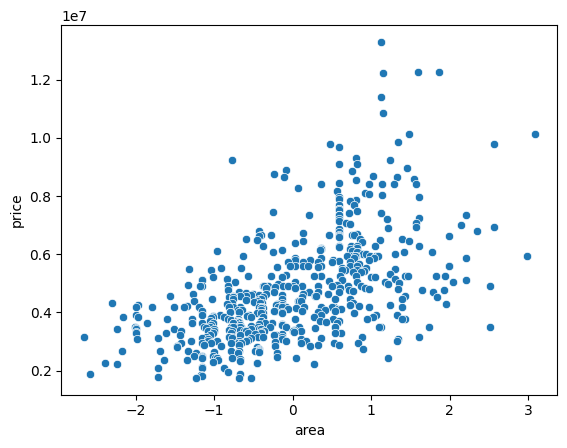

In [45]:
sns.scatterplot(data = df, x = df['area'], y = df['price'])